# Display a map of google

In [79]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import pyarrow
import pandas as pd
import osmnx as ox

In [80]:
# Load roads directly from local Limburg OpenStreetMap PBF file
pbf_path = Path("../limburg-260312.osm.pbf")
if not pbf_path.exists():
    raise FileNotFoundError(f"Could not find: {pbf_path.resolve()}")

roads = gpd.read_file(pbf_path, layer="lines")

# Project for cleaner plotting in meters
roads = roads.to_crs(epsg=3857)

# Loading Limburg map

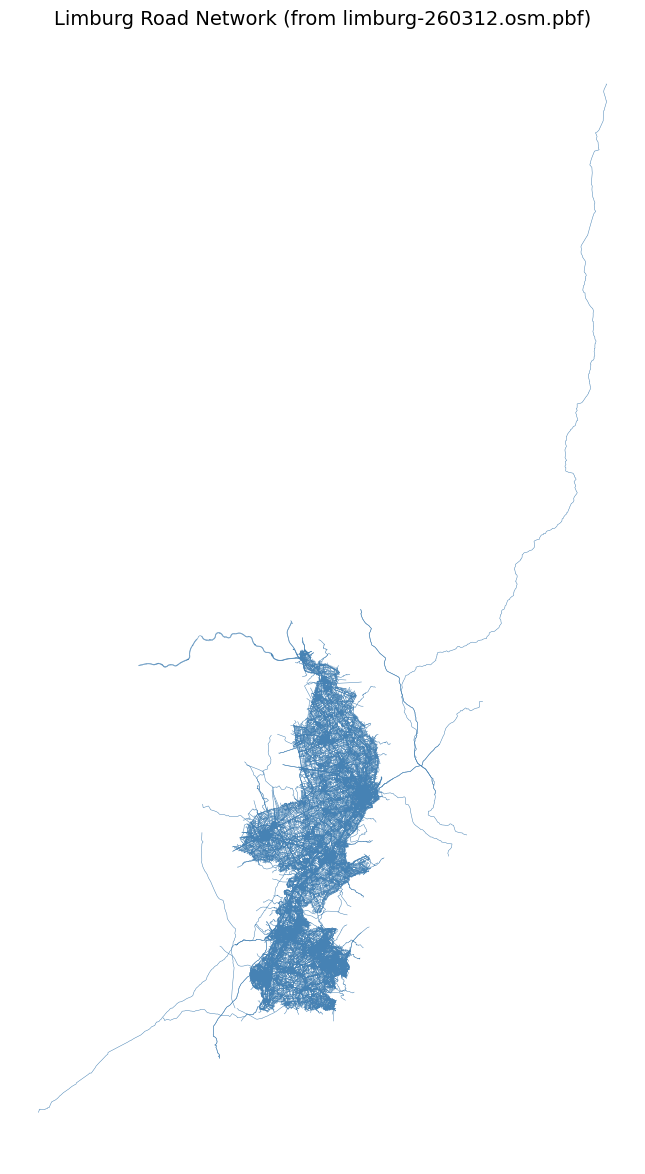

In [81]:
fig, ax = plt.subplots(figsize=(12, 12))
roads.plot(ax=ax, linewidth=0.35, color="steelblue")
ax.set_title("Limburg Road Network (from limburg-260312.osm.pbf)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Zooming in on Heerlen

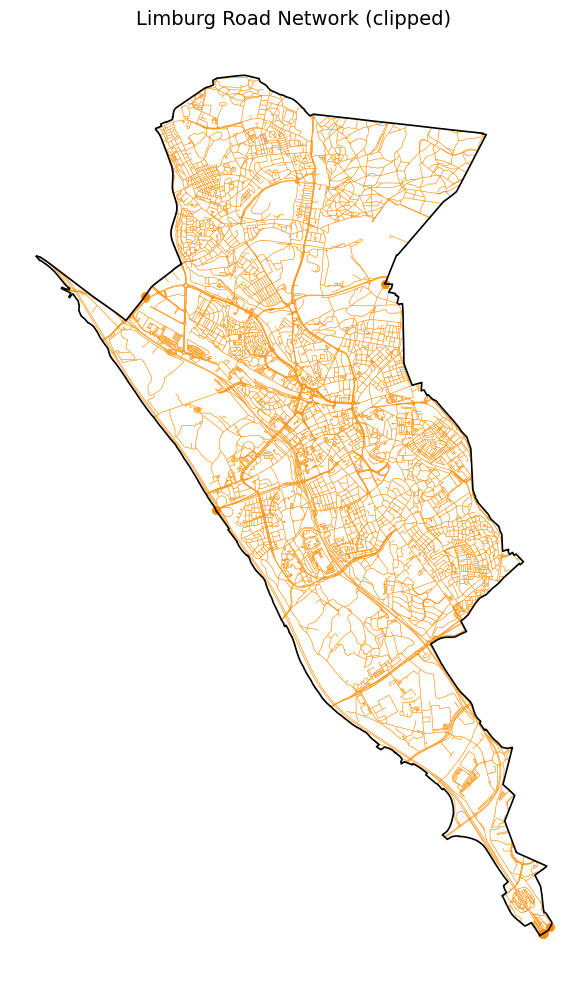

Road segments after clipping: 10,181


In [82]:
# Build Limburg boundary and clip roads to it
limburg_boundary = ox.geocode_to_gdf("Heerlen, Limburg, Netherlands")
limburg_boundary = limburg_boundary.to_crs(roads.crs)
limburg_geom = limburg_boundary.union_all()

# Keep road-like lines and cut segments at the Limburg border
if "highway" in roads.columns:
    roads_for_plot = roads[roads["highway"].notna()].copy()
else:
    roads_for_plot = roads.copy()

roads_limburg = gpd.clip(roads_for_plot, limburg_geom)
roads_limburg = roads_limburg[roads_limburg.geometry.notna() & ~roads_limburg.geometry.is_empty].copy()

fig, ax = plt.subplots(figsize=(10, 10))
roads_limburg.plot(ax=ax, linewidth=0.45, color="darkorange")
limburg_boundary.boundary.plot(ax=ax, linewidth=1.2, color="black")
ax.set_title("Limburg Road Network (clipped)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Road segments after clipping: {len(roads_limburg):,}")

# Testing build-in route maker

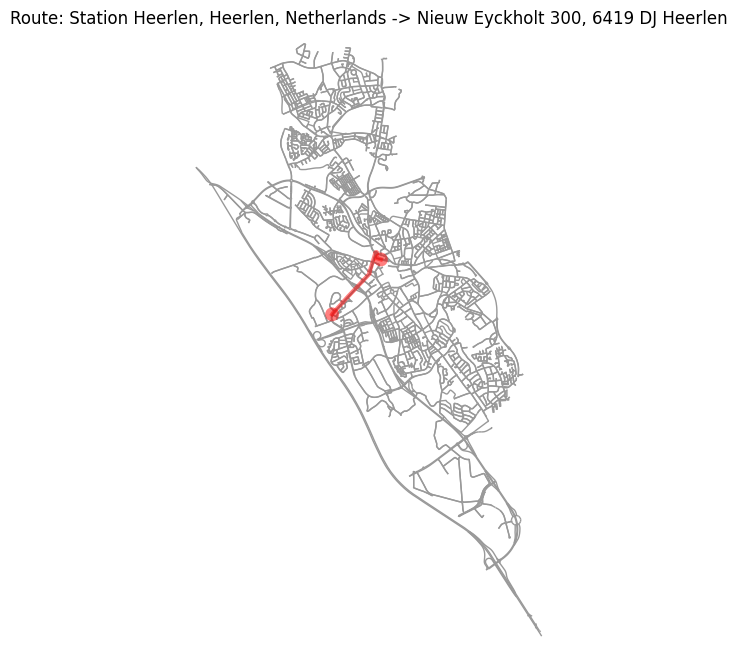

In [83]:
# Set your route endpoints here
start_point = "Station Heerlen, Heerlen, Netherlands"
destination = "Nieuw Eyckholt 300, 6419 DJ Heerlen"

# Build a drivable graph for Heerlen and geocode the two endpoints
route_graph = ox.graph_from_place("Heerlen, Limburg, Netherlands", network_type="drive")
start_lat, start_lon = ox.geocode(start_point)
end_lat, end_lon = ox.geocode(destination)

# Snap endpoints to nearest road nodes and compute shortest path by length
start_node = ox.distance.nearest_nodes(route_graph, X=start_lon, Y=start_lat)
end_node = ox.distance.nearest_nodes(route_graph, X=end_lon, Y=end_lat)
route = ox.shortest_path(route_graph, start_node, end_node, weight="length")

# Plot the route
fig, ax = ox.plot_graph_route(
    route_graph,
    route,
    route_color="red",
    route_linewidth=3,
    node_size=0,
    bgcolor="white",
    show=False,
    close=False,
)
ax.set_title(f"Route: {start_point} -> {destination}", fontsize=12)
plt.show()

# Fetching roads that have speed limit

In [84]:
desired_columns = [
    "osm_id", "name", "highway", "waterway", "aerialway", 
    "barrier", "man_made", "railway", "z_order", "other_tags"
]

roads = gpd.read_file(
    pbf_path, 
    layer="lines", 
    engine="pyogrio",
    columns=desired_columns,
    use_arrow=False
)
# Instead of using other_tags maxspeed, check if the speed_limit column is not null

roads_with_speed = roads[roads['other_tags'].str.contains('maxspeed', na=False)].copy()
roads_with_speed['speed_limit'] = roads_with_speed['other_tags'].str.extract(r'"maxspeed"=>"(\d+)"')

roads_with_speed = roads_with_speed[desired_columns + ['speed_limit', 'geometry']].copy()

In [85]:
roads_with_speed.head(1)




,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,speed_limit,geometry
14,4578867,Von-Byland-Straße,residential,NaN,NaN,NaN,NaN,NaN,3,"""lane_markings""=>""no"",""maxspeed""=>""30"",""zone:m...",30,"LINESTRING (5.87941 51.02503, 5.87947 51.025, ..."


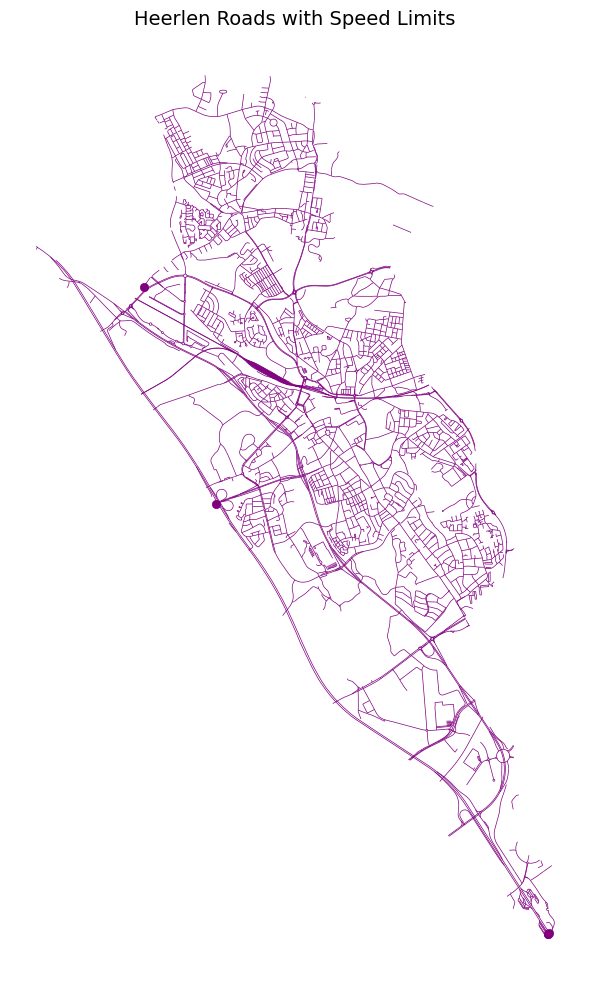

In [86]:
heerlen_boundary = ox.geocode_to_gdf("Heerlen, Limburg, Netherlands").to_crs(roads_with_speed.crs)
roads_heerlen = gpd.clip(roads_with_speed, heerlen_boundary.geometry.iloc[0])

fig, ax = plt.subplots(figsize=(10, 10))
roads_heerlen.plot(ax=ax, linewidth=0.5, color="purple")
ax.set_title("Heerlen Roads with Speed Limits", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()



In [87]:
roads_heerlen.head(1)



,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,speed_limit,geometry
172960,1011042634,Benzenrade,unclassified,NaN,NaN,NaN,NaN,NaN,3,"""cycleway:both""=>""no"",""lane_markings""=>""no"",""m...",60,"LINESTRING (5.97106 50.86277, 5.97115 50.86279..."


# Looking at different types of roads

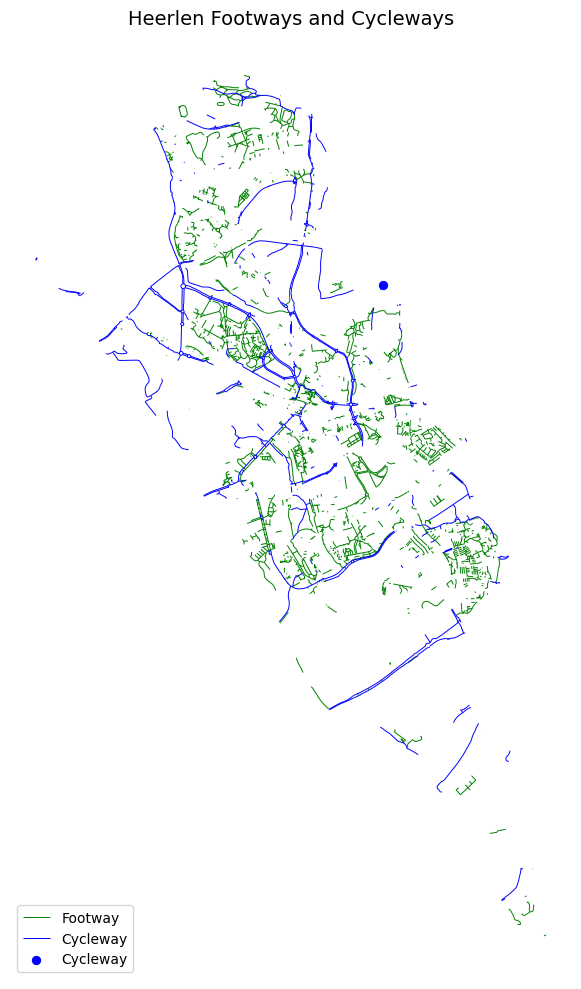

In [88]:
# Add cycleways and footways in Heerlen: footways green, cycleways blue

footway_roads = roads[roads['highway'] == 'footway'].copy()
footway_roads = footway_roads[footway_roads.geometry.notna() & ~footway_roads.geometry.is_empty].copy()

cycleway_roads = roads[roads['highway'] == 'cycleway'].copy()
cycleway_roads = cycleway_roads[cycleway_roads.geometry.notna() & ~cycleway_roads.geometry.is_empty].copy()

heerlen_geom = heerlen_boundary.geometry.iloc[0]
footway_heerlen = gpd.clip(footway_roads, heerlen_geom)
cycleway_heerlen = gpd.clip(cycleway_roads, heerlen_geom)

fig, ax = plt.subplots(figsize=(10, 10))
footway_heerlen.plot(ax=ax, linewidth=0.7, color="green", label="Footway")
cycleway_heerlen.plot(ax=ax, linewidth=0.7, color="blue", label="Cycleway")
ax.set_title("Heerlen Footways and Cycleways", fontsize=14)
ax.set_axis_off()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [89]:
# load in this csv clients.csv
clients = pd.read_csv("../output/clients.csv")

addresses = clients["address"].copy()
addresses.head(3)

0    Kloosterkoolhof 26D, 6415XT Heerlen
1     Frans Halsstraat 6, 6415TH Heerlen
2           Hertstraat 1, 6414CH Heerlen
Name: address, dtype: str

In [90]:
roads_heerlen.head(1)



,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,speed_limit,geometry
172960,1011042634,Benzenrade,unclassified,NaN,NaN,NaN,NaN,NaN,3,"""cycleway:both""=>""no"",""lane_markings""=>""no"",""m...",60,"LINESTRING (5.97106 50.86277, 5.97115 50.86279..."


# Heerlen edge table creator

In [100]:
# Build edge-level connectivity + travel time tables from the routing graph
import numpy as np

# 1) Add speed and travel time attributes (travel_time in seconds)
route_graph_tt = ox.add_edge_speeds(route_graph)
route_graph_tt = ox.add_edge_travel_times(route_graph_tt)

# 2) Convert graph edges to a table
edges_gdf = ox.graph_to_gdfs(route_graph_tt, nodes=False, edges=True).reset_index()

# Keep common attributes if present
cols = ["u", "v", "key", "name", "highway", "length", "speed_kph", "travel_time", "geometry"]
edge_table = edges_gdf[[c for c in cols if c in edges_gdf.columns]].copy()

# Clean name/highway fields (they can be lists)
def _to_text(value):
    if isinstance(value, list):
        return " | ".join(map(str, value))
    return value

if "name" in edge_table.columns:
    edge_table["name"] = edge_table["name"].apply(_to_text)
if "highway" in edge_table.columns:
    edge_table["highway"] = edge_table["highway"].apply(_to_text)

# Add human-readable travel time
if "travel_time" in edge_table.columns:
    edge_table["travel_time_min"] = edge_table["travel_time"] / 60.0

print(f"Directed road segments (edges): {len(edge_table):,}")
edge_table.head(10)

# 4) Route-specific breakdown
route_pairs = list(zip(route[:-1], route[1:]))
route_rows = []
for u, v in route_pairs:
    edge_data = route_graph_tt.get_edge_data(u, v)
    if not edge_data:
        continue
    # choose the fastest parallel edge if multiple exist
    best_key, best_attrs = min(edge_data.items(), key=lambda kv: kv[1].get("travel_time", np.inf))
    route_rows.append({
        "u": u,
        "v": v,
        "key": best_key,
        "name": _to_text(best_attrs.get("name")),
        "highway": _to_text(best_attrs.get("highway")),
        "length_m": best_attrs.get("length"),
        "speed_kph": best_attrs.get("speed_kph"),
        "travel_time_s": best_attrs.get("travel_time"),
        "travel_time_min": (best_attrs.get("travel_time") / 60.0) if best_attrs.get("travel_time") is not None else None,
    })

route_breakdown = pd.DataFrame(route_rows)
print("Route segment breakdown:")
display(route_breakdown.head(20))

if not route_breakdown.empty:
    total_len_km = route_breakdown["length_m"].sum() / 1000.0
    total_time_min = route_breakdown["travel_time_min"].sum()
    print(f"Total route length: {total_len_km:.2f} km")
    print(f"Estimated route time: {total_time_min:.1f} minutes")

# Optional exports for external use
edge_table.to_csv("../output/heerlen_edge_table.csv", index=False)

Directed road segments (edges): 6,824
Route segment breakdown:


,u,v,key,name,highway,length_m,speed_kph,travel_time_s,travel_time_min
0,1529791500,6742883936,0,Melkweg,busway,154.761783,15.0,37.142828,0.619047
1,6742883936,1529791529,0,Melkweg,busway,7.548923,50.0,0.543522,0.009059
2,1529791529,1529791591,0,Melkweg,busway,10.922278,50.0,0.786404,0.013107
3,1529791591,597499342,0,Melkweg,busway,15.829936,50.0,1.139755,0.018996
4,597499342,6742883970,0,NaN,busway,8.030671,50.0,0.578208,0.009637
5,6742883970,6742872252,0,NaN,secondary,14.802078,50.0,1.065750,0.017762
6,6742872252,6742872279,0,NaN,secondary,46.570519,50.0,3.353077,0.055885
7,6742872279,453163380,0,NaN,secondary,15.958472,50.0,1.149010,0.019150
8,453163380,6742883984,0,NaN,secondary,10.368133,50.0,0.746506,0.012442
9,6742883984,1927699986,0,Looierstraat,secondary,333.487378,50.0,24.011091,0.400185


Total route length: 1.90 km
Estimated route time: 2.7 minutes


# Visualization of the line segments

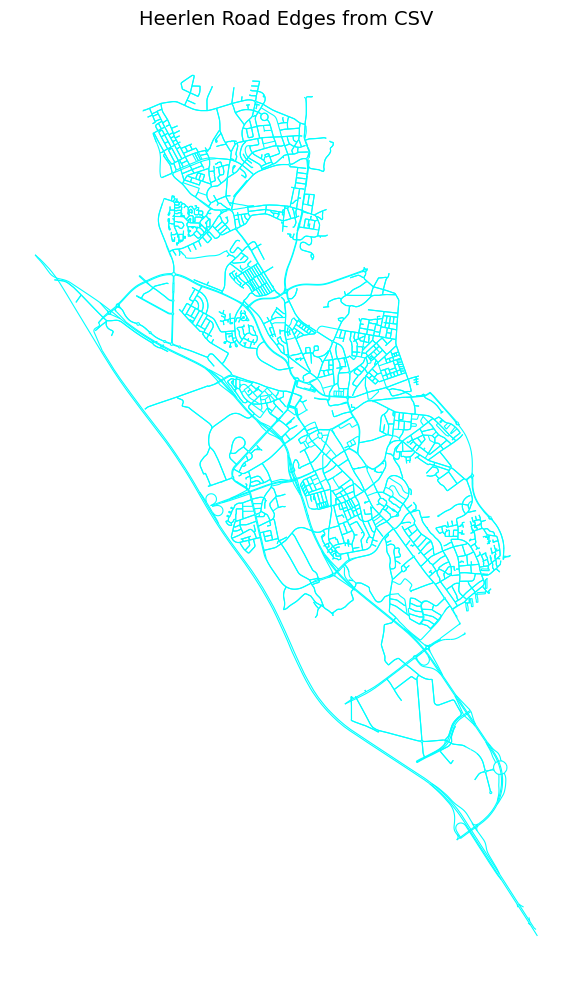

In [92]:
# plot all the edges from ../output/heerlen_edge_table.csv
edges_df = pd.read_csv("../output/heerlen_edge_table.csv")
edges_gdf = gpd.GeoDataFrame(
    edges_df,
    geometry=gpd.GeoSeries.from_wkt(edges_df["geometry"]),
    crs="EPSG:4326"
)
edges_gdf = edges_gdf.to_crs(epsg=3857)
edges_gdf.plot(figsize=(10, 10), color="cyan", linewidth=0.8)
plt.title("Heerlen Road Edges from CSV", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


## Now seperated on type of road

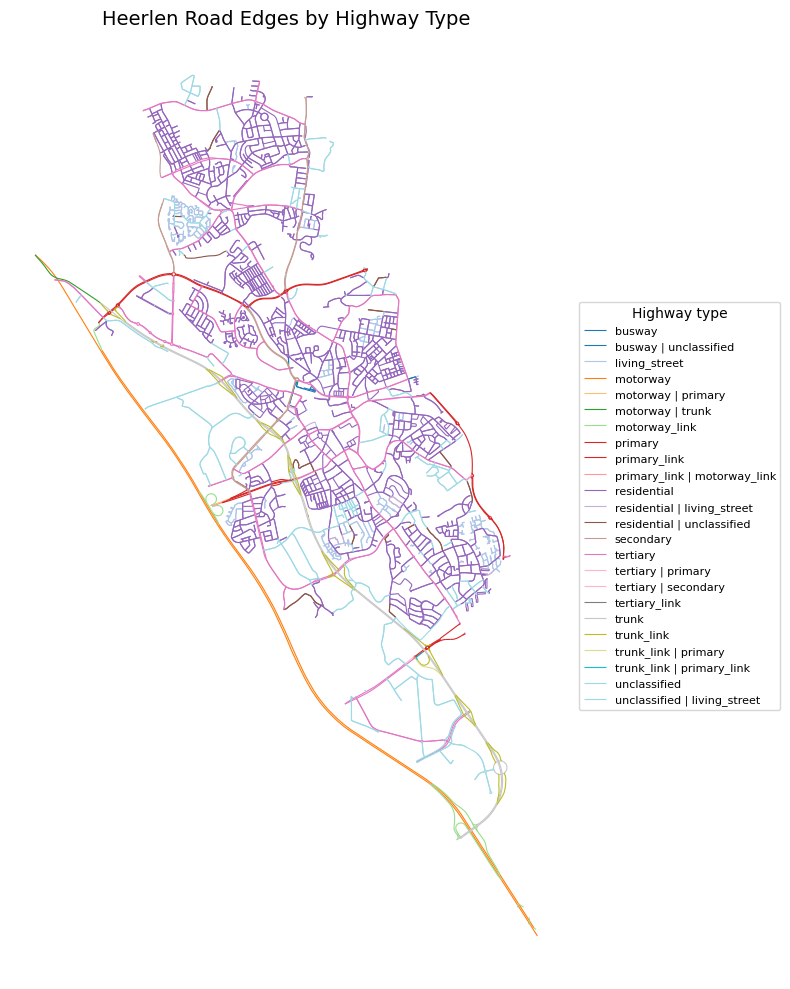

In [93]:
# Plot with one colour per highway type, including missing values as "unknown"
segments = edges_gdf.copy()

if segments.crs is None or segments.crs.to_epsg() != 3857:
    segments = segments.to_crs(epsg=3857)

segments["highway_plot"] = segments["highway"].fillna("unknown").astype(str).str.strip()
segments.loc[segments["highway_plot"] == "", "highway_plot"] = "unknown"

highway_types = sorted(segments["highway_plot"].unique())
cmap = plt.get_cmap("tab20", max(len(highway_types), 1))

fig, ax = plt.subplots(figsize=(10, 10))
for i, hwy in enumerate(highway_types):
    segments[segments["highway_plot"] == hwy].plot(
        ax=ax,
        color=cmap(i),
        linewidth=0.8,
        label=hwy
    )

ax.set_title("Heerlen Road Edges by Highway Type", fontsize=14)
ax.set_axis_off()
ax.legend(title="Highway type", loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()


# Analysing different data inside the map

In [94]:
from pathlib import Path

import geopandas as gpd

# Find the PBF file from common relative locations
candidate_paths = [
    Path("limburg-260312.osm.pbf"),
    Path("../limburg-260312.osm.pbf"),
]
pbf_path = next((p for p in candidate_paths if p.exists()), None)
if pbf_path is None:
    raise FileNotFoundError("Could not find limburg-260312.osm.pbf in current or parent folder.")

# List layers using pyogrio
import pyogrio

layer_info = pyogrio.list_layers(pbf_path)
layers = [name for name, _geom in layer_info]
print("Layers found (pyogrio):")
for name, geom in layer_info:
    print(f"- {name} (geometry: {geom})")

if not layers:
    raise ValueError("No layers found in the PBF file.")



Layers found (pyogrio):
- points (geometry: Point)
- lines (geometry: LineString)
- multilinestrings (geometry: MultiLineString)
- multipolygons (geometry: MultiPolygon)
- other_relations (geometry: GeometryCollection)


## Displaying each data layer

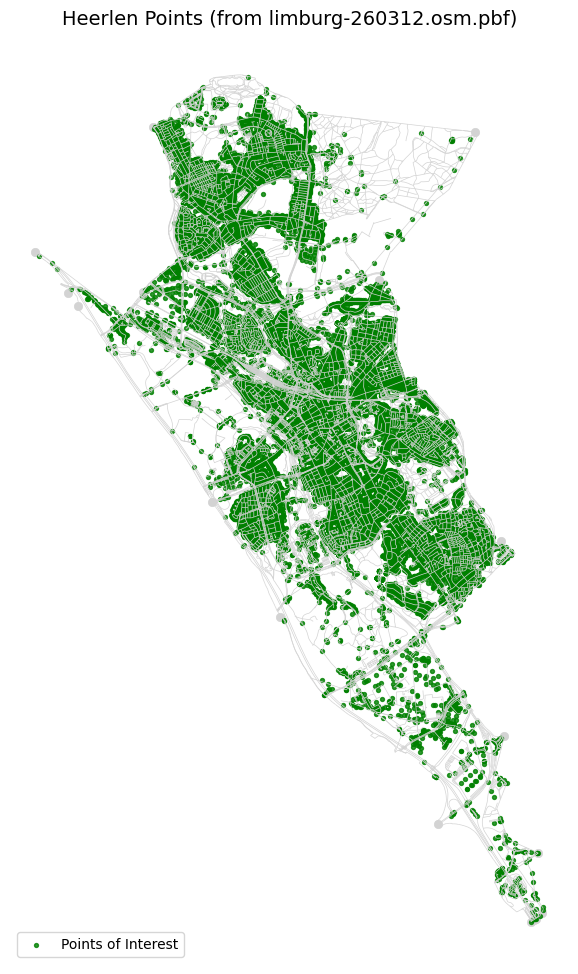

Total points in PBF: 794272
Points within Heerlen: 48119
Sample points data:


,osm_id,name,barrier,highway,ref,address,is_in,place,man_made,other_tags,geometry
754620,11841858741,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,"""addr:city""=>""Heerlen"",""addr:housenumber""=>""30...",POINT (664447.094 6597971.849)


In [95]:
# Load points and filter to Heerlen only
points = gpd.read_file(pbf_path, layer="points")
points = points.to_crs(epsg=3857)

# Get Heerlen boundary and clip points to it
heerlen_boundary = ox.geocode_to_gdf("Heerlen, Limburg, Netherlands").to_crs(points.crs)
points_heerlen = gpd.clip(points, heerlen_boundary.geometry.iloc[0])

# Also clip roads to Heerlen for context
roads = gpd.read_file(pbf_path, layer="lines")
roads = roads.to_crs(epsg=3857)
roads_heerlen = gpd.clip(roads, heerlen_boundary.geometry.iloc[0])

# Plot together
fig, ax = plt.subplots(figsize=(10, 10))
roads_heerlen.plot(ax=ax, linewidth=0.5, color="lightgray")
points_heerlen.plot(ax=ax, color="green", markersize=8, alpha=0.8, label="Points of Interest")

ax.set_title("Heerlen Points (from limburg-260312.osm.pbf)", fontsize=14)
ax.set_axis_off()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Total points in PBF: {len(points)}")
print(f"Points within Heerlen: {len(points_heerlen)}")

# Head the pandas DataFrame of points to see available attributes
print("Sample points data:")
points_heerlen.head(1)

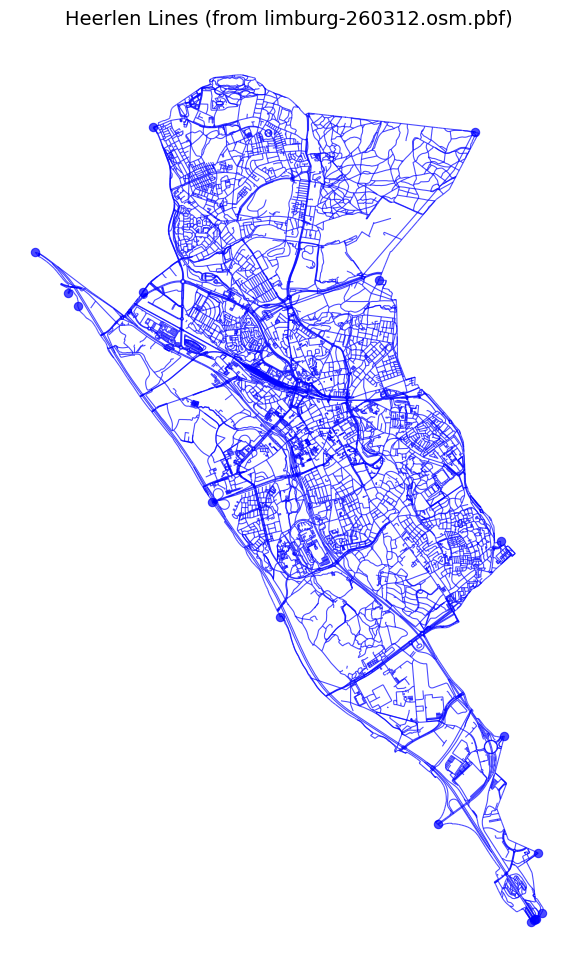

Total lines in PBF: 238605
Lines within Heerlen: 11694
Sample lines data:


,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,geometry
55589,115300245,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,"""cables""=>""6"",""circuits""=>""2"",""frequency""=>""50...","MULTILINESTRING ((669371.925 6597417.304, 6692..."


In [96]:
# Load and plot Lines layer (LineString) filtered to Heerlen
lines = gpd.read_file(pbf_path, layer="lines")
lines = lines.to_crs(epsg=3857)
lines_heerlen = gpd.clip(lines, heerlen_boundary.geometry.iloc[0])

fig, ax = plt.subplots(figsize=(10, 10))
lines_heerlen.plot(ax=ax, linewidth=0.8, color="blue", alpha=0.7)
ax.set_title("Heerlen Lines (from limburg-260312.osm.pbf)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Total lines in PBF: {len(lines)}")
print(f"Lines within Heerlen: {len(lines_heerlen)}")

# Head the pandas DataFrame of lines to see available attributes
print("Sample lines data:")
lines_heerlen.head(1)


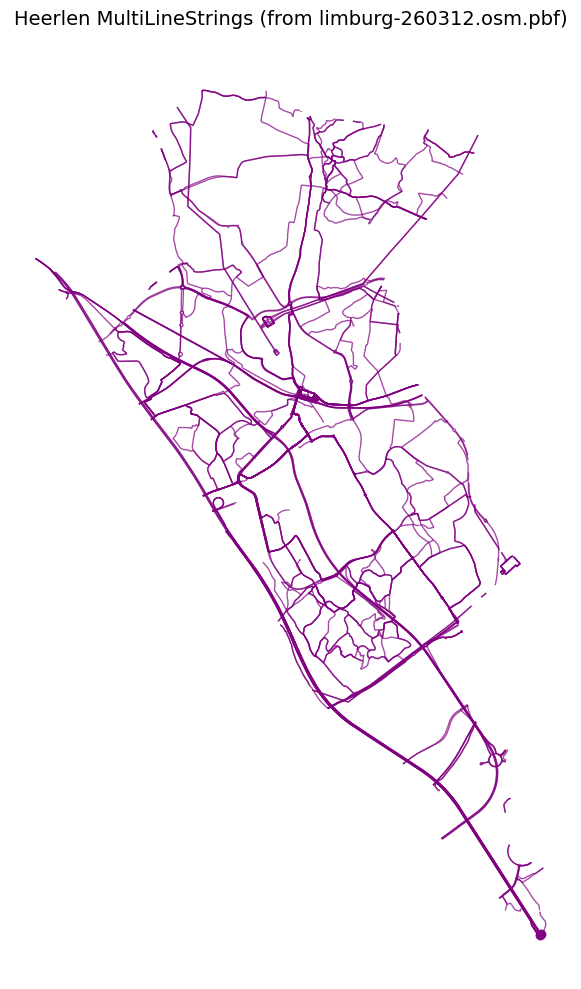

Total multilinestrings in PBF: 9151
MultiLineStrings within Heerlen: 219
Sample multilinestrings data:


,osm_id,name,type,other_tags,geometry
7351,11561250,"Flixbus 328: Lille, Boulevard de Turin => Fran...",route,"""from""=>""Lille, Boulevard de Turin"",""headway""=...","MULTILINESTRING ((663181.505 6598894.505, 6632..."


In [97]:
# Load and plot MultiLineStrings layer (MultiLineString) filtered to Heerlen
multilinestrings = gpd.read_file(pbf_path, layer="multilinestrings")
multilinestrings = multilinestrings.to_crs(epsg=3857)
multilinestrings_heerlen = gpd.clip(multilinestrings, heerlen_boundary.geometry.iloc[0])

fig, ax = plt.subplots(figsize=(10, 10))
multilinestrings_heerlen.plot(ax=ax, linewidth=1.0, color="purple", alpha=0.7)
ax.set_title("Heerlen MultiLineStrings (from limburg-260312.osm.pbf)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Total multilinestrings in PBF: {len(multilinestrings)}")
print(f"MultiLineStrings within Heerlen: {len(multilinestrings_heerlen)}")

# Head the pandas DataFrame of multilinestrings to see available attributes
print("Sample multilinestrings data:")
multilinestrings_heerlen.head(1)


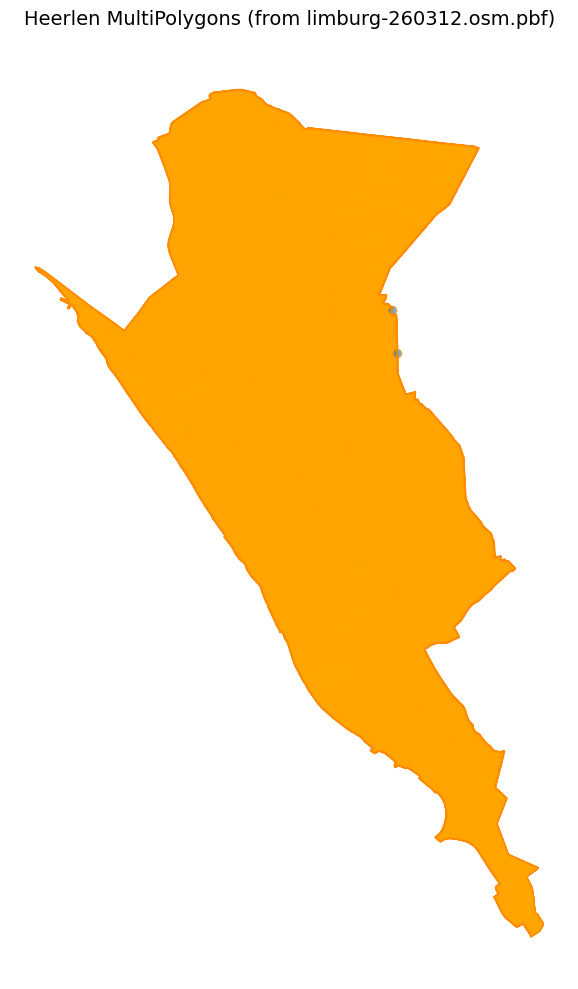

Total multipolygons in PBF: 1046551
MultiPolygons within Heerlen: 48460
Sample multipolygons data:


,osm_id,osm_way_id,name,type,aeroway,amenity,admin_level,barrier,boundary,building,...,man_made,military,natural,office,place,shop,sport,tourism,other_tags,geometry
2700,2721306,NaN,Bocholtz,boundary,NaN,NaN,10,NaN,administrative,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""authoritative""=>""yes"",""ref:woonplaatscode""=>""...","MULTILINESTRING ((670557.777 6589233.698, 6705..."


In [98]:
# Load and plot MultiPolygons layer (MultiPolygon) filtered to Heerlen
multipolygons = gpd.read_file(pbf_path, layer="multipolygons")
multipolygons = multipolygons.to_crs(epsg=3857)
multipolygons_heerlen = gpd.clip(multipolygons, heerlen_boundary.geometry.iloc[0])

fig, ax = plt.subplots(figsize=(10, 10))
multipolygons_heerlen.plot(ax=ax, facecolor="orange", edgecolor="darkorange", alpha=0.6)
ax.set_title("Heerlen MultiPolygons (from limburg-260312.osm.pbf)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Total multipolygons in PBF: {len(multipolygons)}")
print(f"MultiPolygons within Heerlen: {len(multipolygons_heerlen)}")

# Head the pandas DataFrame of multipolygons to see available attributes
print("Sample multipolygons data:")
multipolygons_heerlen.head(1)

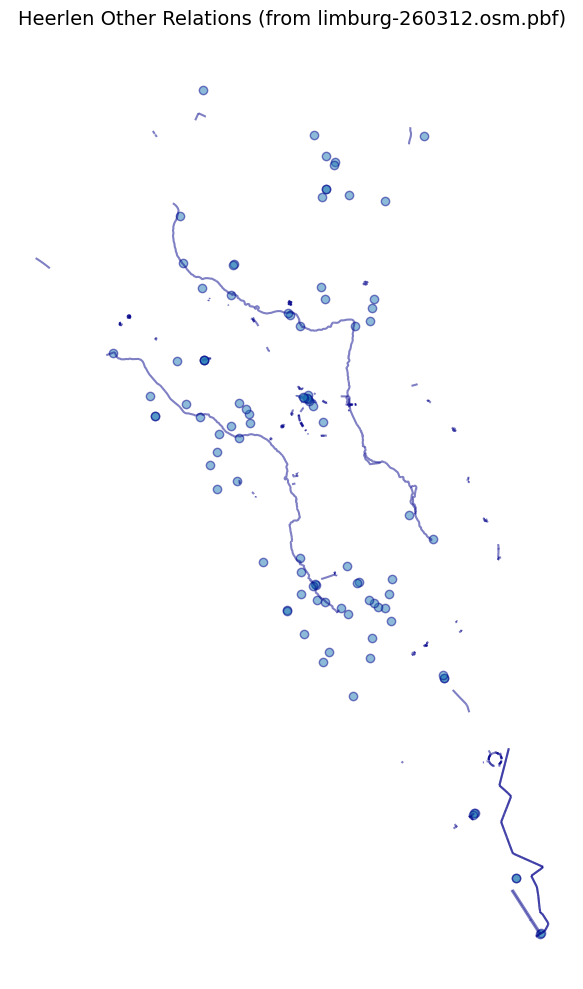

Total other_relations in PBF: 1766
Other relations within Heerlen: 194
Sample other_relations data:


,osm_id,name,type,other_tags,geometry
1285,16115548,NaN,restriction,"""restriction""=>""only_straight_on""","MULTILINESTRING ((660652.023 6603761.214, 6606..."


In [99]:
# Load and plot Other Relations layer (GeometryCollection) filtered to Heerlen
other_relations = gpd.read_file(pbf_path, layer="other_relations")
other_relations = other_relations.to_crs(epsg=3857)
other_relations_heerlen = gpd.clip(other_relations, heerlen_boundary.geometry.iloc[0])

fig, ax = plt.subplots(figsize=(10, 10))
other_relations_heerlen.plot(ax=ax, facecolor="cyan", edgecolor="darkblue", alpha=0.5)
ax.set_title("Heerlen Other Relations (from limburg-260312.osm.pbf)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Total other_relations in PBF: {len(other_relations)}")
print(f"Other relations within Heerlen: {len(other_relations_heerlen)}")

# Head the pandas DataFrame of other_relations to see available attributes
print("Sample other_relations data:")
other_relations_heerlen.head(1)